# 1: Import the dataset



Downloading...
From: https://drive.google.com/uc?id=1rTaPiywHRLKe5BS0bSbj06P_C3qXQK4X
To: /content/shots.csv
100%|██████████| 37.8M/37.8M [00:00<00:00, 145MB/s]



--- LOGISTIC REGRESSION ---
Beste Parameter LogReg: {'model__C': np.float64(10000.0)}

--- LIGHTGBM ---
Beste Struktur-Parameter LightGBM gefunden: {'colsample_bytree': np.float64(0.9702468904459353), 'max_depth': -1, 'min_child_samples': 50, 'num_leaves': 95, 'reg_alpha': np.float64(0.5337803296794219), 'reg_lambda': np.float64(1.678300323984816), 'subsample': np.float64(0.5018079423373394), 'learning_rate': 0.01}
Starte 5-Fold Cross-Validation für Early Stopping (100% Daten-Ausbeute)...
Optimaler Stopp-Punkt gefunden bei exakt 482 Bäumen.

--- MLP ---
Beste Parameter MLP: {'model__alpha': np.float64(0.009932308858067881), 'model__hidden_layer_sizes': (64,), 'model__learning_rate_init': np.float64(0.0007322520635999886)}

EVALUIERUNGSERGEBNISSE

--- Logistic Regression ---
Log Loss:      0.2662 (Je kleiner, desto besser)
Brier Score:   0.0757 (Je kleiner, desto besser)
AUC-ROC:       0.8108 (Je näher an 1, desto besser)
ECE:           0.0034 (Je kleiner, desto besser)
vs xGoal: MAE=0

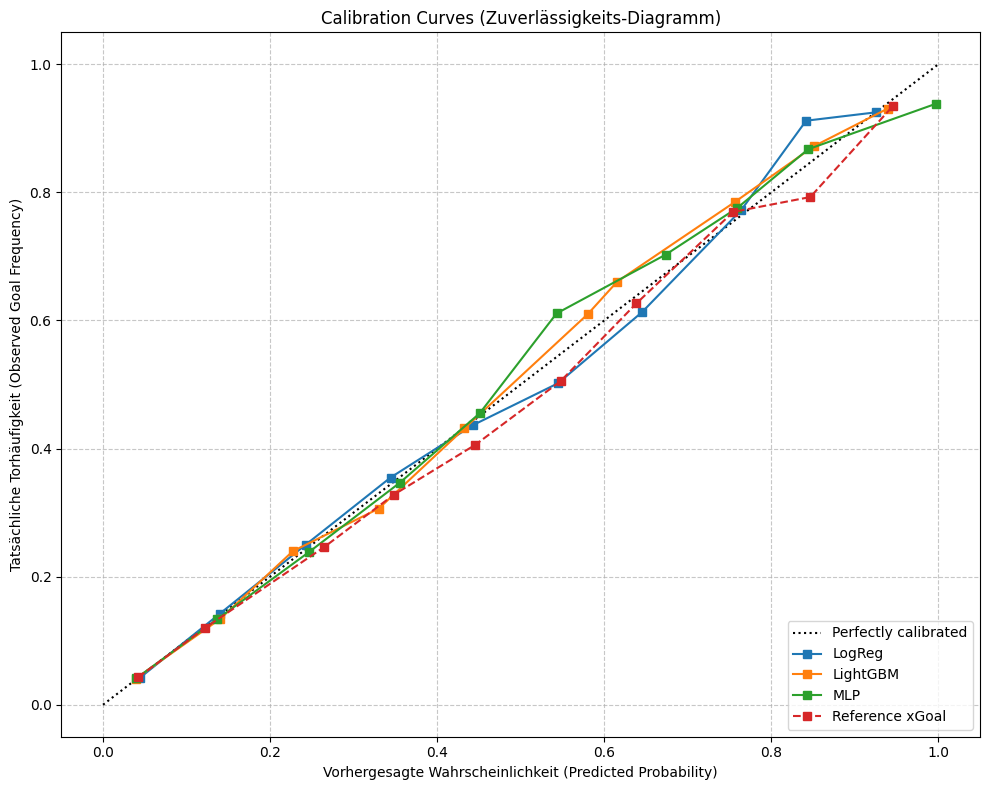

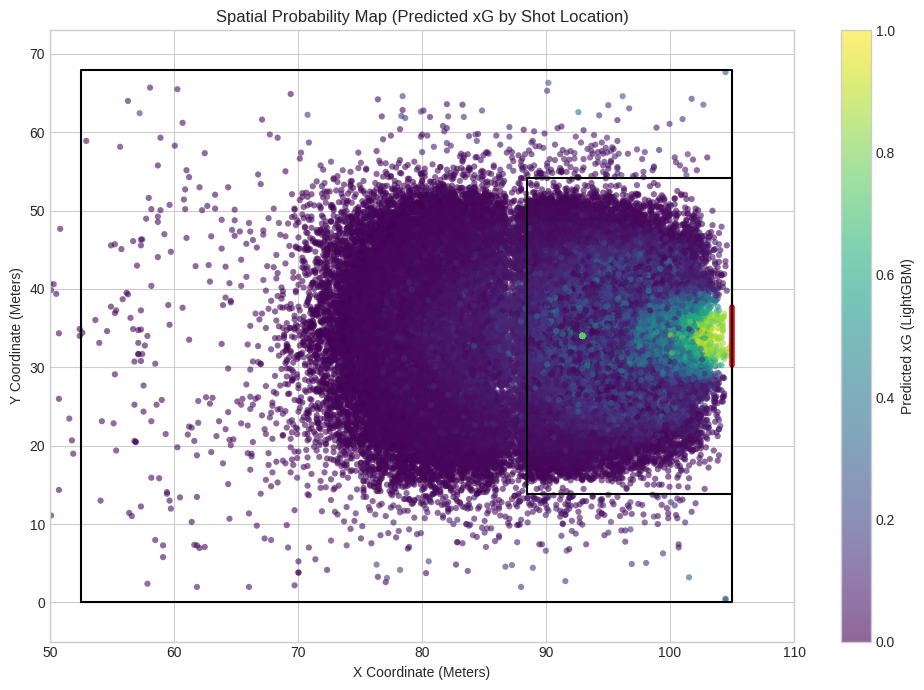

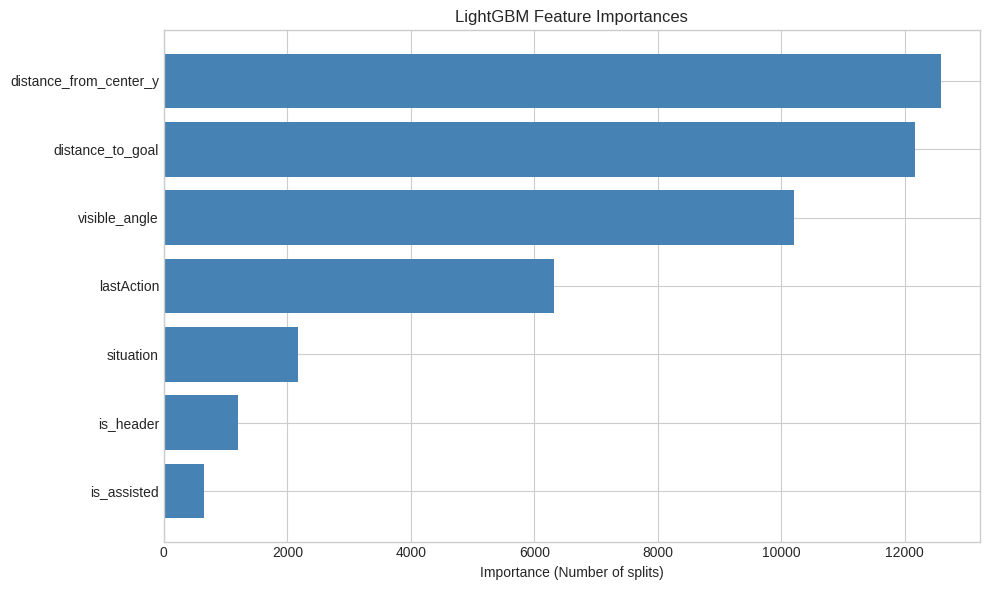

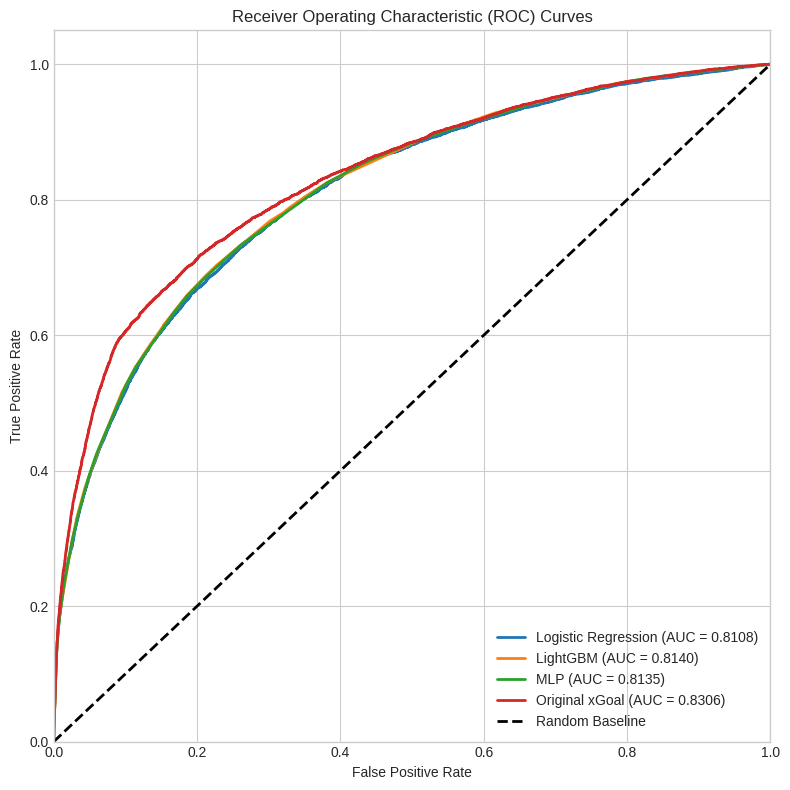

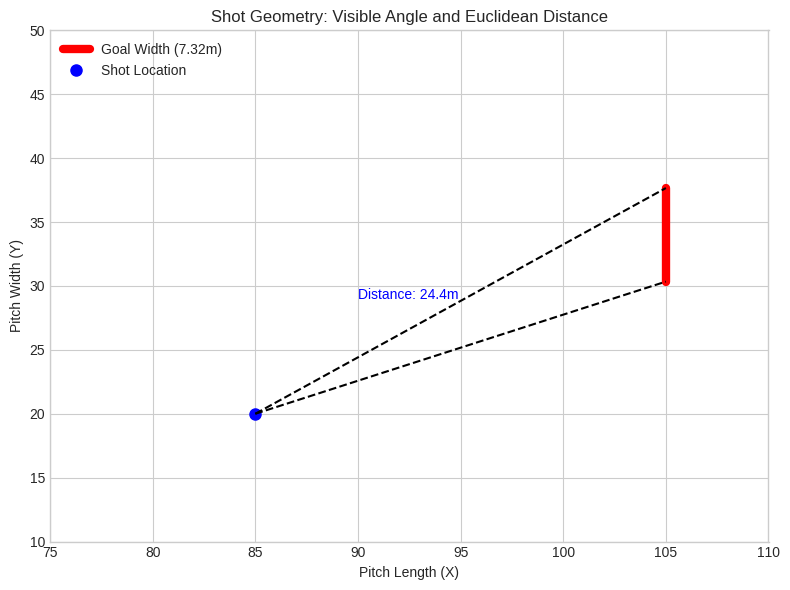

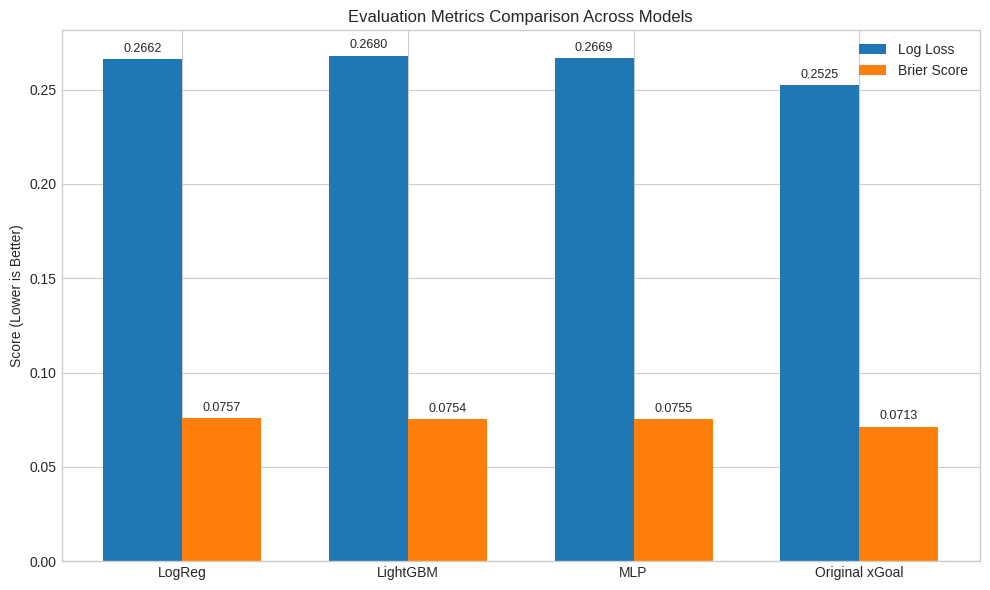

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
import joblib
import gdown
from scipy.stats import randint, uniform
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import (
    log_loss,
    roc_auc_score,
    brier_score_loss,
    mean_absolute_error
)

# ==========================================
# SEEDS FOR REPRODUCEABILITY
# ==========================================
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ==========================================
# 1. LOAD DATA FROM CSV FILE
# ==========================================
file_id = "1rTaPiywHRLKe5BS0bSbj06P_C3qXQK4X"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "shots.csv", quiet=False)
df = pd.read_csv("shots.csv")

# ==========================================
# 2. DATA CLEANUP
# ==========================================
# REMOVE OWN GOALS AS THEY ARE NOT SHOTS AND WOULD JUST CONFUSE THE MODELS
df = df[df["shotResult"] != "OwnGoal"].copy()

# SAVE IF THE SHOT WAS A GOAL IN A NEW COLUMN
df["is_goal"] = (df["shotResult"] == "Goal").astype(int)
# FILL MISSING VALUES
df["is_assisted"] = (df["assisterID"].notna()).astype(int)
df["lastAction"] = df["lastAction"].fillna("Unknown")

# ==========================================
# 3. CALCULATE CORRECT POSITION ON THE FIELD
# ==========================================
FIELD_LENGTH = 105 # Standard football field values
FIELD_WIDTH = 68 # Standard football field values

df["x_meters"] = df["positionX"] * FIELD_LENGTH
df["y_meters"] = df["positionY"] * FIELD_WIDTH

GOAL_X = FIELD_LENGTH
GOAL_CENTER_Y = FIELD_WIDTH / 2
GOAL_WIDTH = 7.32 # Standard football goal size

GOAL_Y1 = GOAL_CENTER_Y - (GOAL_WIDTH / 2)
GOAL_Y2 = GOAL_CENTER_Y + (GOAL_WIDTH / 2)

# CALCULATE THE ANGLE OF THE SHOT
def calculate_visible_angle(x, y):
    v1_x = GOAL_X - x
    v1_y = GOAL_Y1 - y
    v2_x = GOAL_X - x
    v2_y = GOAL_Y2 - y

    angle1 = np.arctan2(v1_y, v1_x)
    angle2 = np.arctan2(v2_y, v2_x)

    angle = np.abs(angle1 - angle2)
    angle = np.where(angle > np.pi, 2 * np.pi - angle, angle)

    # IF THE SHOT IS TAKEN FROM THE LINE OR BEHIND (DATA QUALITY ERROR) SET THE ANGLE TO 0
    angle = np.where(x >= GOAL_X, 0, angle)

    return np.degrees(angle)

# STORE THE ANGLE AND THE DISTANCE IN A NEW COLUMN
df["visible_angle"] = calculate_visible_angle(df["x_meters"], df["y_meters"])
df["distance_to_goal"] = np.hypot(GOAL_X - df["x_meters"], GOAL_CENTER_Y - df["y_meters"])

# ==========================================
# FEATURE ENGINEERING
# ==========================================
# STORE IF THE SHOT WAS A HEADER IN A NEW COLUMN
df["is_header"] = (df["shotType"] == "Head").astype(int)
# ADD SQUARED DISTANCE OF THE SHOT TO PUNISH LONG RANGE SHOTS
df["distance_squared"] = df["distance_to_goal"] ** 2
# USE LOGARITHMIC DISTANCE AS THE DIFFERENCE BETWEEN 0 AND 1 METERS IS MUCH MORE IMPORTANT THAN BETWEEN 40 AND 41 METERS
df["log_distance_to_goal"] = np.log1p(df["distance_to_goal"])
# ANGLE DISTANCE INTERACTION - HIGHER IS WORSE AS IT IS FURTHER AWAY AND A GREATER ANGLE
df["angle_distance_interaction"] = df["visible_angle"] * df["distance_to_goal"]
# SAVE THE Y OFFSET OF THE SHOT FROM THE MIDDLE
df["distance_from_center_y"] = np.abs(GOAL_CENTER_Y - df["y_meters"])

# ==========================================
# MODEL-SPECIFIC FEATURE SETTING
# ==========================================
# DEFINE FEATURES FOR MODELS - TREE (LIGHT GBM NEEDS DIFFERENT FEATURES)
categorical_features = ["situation", "lastAction"]

numeric_features_linear = [
    "distance_to_goal", "visible_angle", "is_assisted", "is_header",
    "distance_from_center_y", "distance_squared",
    "angle_distance_interaction", "log_distance_to_goal"
]

numeric_features_tree = [
    "distance_to_goal", "visible_angle", "is_assisted",
    "is_header", "distance_from_center_y"
]

# SAVE COLUMNS AS CATEGORIES FOR LIGHT GBM
for col in categorical_features:
    df[col] = df[col].astype("category")

# STORE THE RESULT FROM THE "EXPERT MODEL" IN A SEPARATE COLUMN
xg_reference = df["xGoal"]

# DROP UNNECESSARY COLUMNS
columns_to_drop = ["gameID", "shooterID", "assisterID", "shotResult", "xGoal", "shotType", "positionX", "positionY", "x_meters", "y_meters"]
df = df.drop(columns=columns_to_drop)

# DROP THIS COLUMN TO PREVENT DATA LEAKAGE
target = "is_goal"
X = df.drop(columns=[target])
y = df[target]

# ==========================================
# 4. DATA Split (70% Train, 10% Calib, 20% Test)
# ==========================================
# 70% TRAINING DATA
# PASS XG_REFERENCE THROUGH THE SPLIT TO KEEP THE CONNECTION BETWEEN THE ROWS
X_train_cv, X_temp, y_train_cv, y_temp, xg_train_ref, xg_temp_ref = train_test_split(
    X, y, xg_reference, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

# THE REMAINING 30% ARE DIVIDED INTO 10% CALIBRATION AND 20% TEST DATA
X_calib, X_test, y_calib, y_test, xg_calib_ref, xg_test_ref = train_test_split(
    X_temp, y_temp, xg_temp_ref, test_size=0.666, stratify=y_temp, random_state=RANDOM_STATE
)

# ==========================================
# 7. PREPROCESSING FOR LINEAR MODELS
# ==========================================
# USE STANDARDSCALER FOR NUMERIC FEATURES AND ONE HOT ENCODER FOR CATEGORIAL FEATURES
preprocessor_linear = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_linear),
        ("cat", OneHotEncoder(drop=None, handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

# SPLIT DATA INTO n FOLDS AND USE BLOCK ONE FOR TEST AND THE OTHERS AS TRAIN. EVERY BLOCK WILL BE USED FOR TEST ONCE
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ==========================================
# 8. LOGISTIC REGRESSION
# ==========================================
print("\n--- LOGISTIC REGRESSION ---")

# CREATE A PIPELINE FOR LOGISTIC REGRESSION
pipeline_logreg = Pipeline([
    ("preprocessing", preprocessor_linear),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

# DEFINE THE SEARCH SPACE FOR LOGISTIC REGRESSION
param_grid_logreg = {"model__C": np.logspace(-4, 4, 20)}

# USE GRIDSEARCH TO FIND THE BEST PARAMETERS
grid_logreg = GridSearchCV(
    estimator=pipeline_logreg, param_grid=param_grid_logreg,
    scoring="neg_log_loss", cv=cv_strategy, n_jobs=-1
)

# TRAIN THE LOGREG WITH 70% DATA AND AND FIND BEST PARAMETERS
grid_logreg.fit(X_train_cv, y_train_cv)

# PRINT THE BEST PARAMETERS
print("Beste Parameter LogReg:", grid_logreg.best_params_)

# USE THE MODEL ON THE TEST SET
xg_logreg = grid_logreg.predict_proba(X_test)[:, 1]

# ==========================================
# 9. DATA PREPARATION FOR LIGHTGBM
# ==========================================
features_tree = numeric_features_tree + categorical_features

X_train_tree = X_train_cv[features_tree].copy()
X_calib_tree = X_calib[features_tree].copy()
X_test_tree = X_test[features_tree].copy()

# ==========================================
# 10. LIGHTGBM (CROSS-VALIDATION MASTERCLASS)
# ==========================================
print("\n--- LIGHTGBM ---")

# PHASE 1: UNBIASED PARAMETER SEARCH
lgbm_search_model = lgb.LGBMClassifier(
    objective="binary", random_state=RANDOM_STATE, n_jobs=-1,
    n_estimators=100, learning_rate=0.01, verbose=-1
)

# SEARCH SPACET
param_dist_lgb = {
    "num_leaves": randint(20, 120),
    "max_depth": [3, 5, 7, -1],
    "min_child_samples": [20, 50, 100],
    "colsample_bytree": uniform(0.4, 0.6),
    "subsample": uniform(0.4, 0.6),
    "reg_alpha": uniform(0, 5),
    "reg_lambda": uniform(0, 5)
}

# USE RANDOMIZED SEARCH INSTEAD OF GRID SEARCH BECAUSE THE PARAMETER SPACE IS TOO HUGE TO TEST EVERY SINGLE COMBINATION
random_search_lgb = RandomizedSearchCV(
    estimator=lgbm_search_model, param_distributions=param_dist_lgb,
    n_iter=100, scoring="neg_log_loss", cv=cv_strategy,
    random_state=RANDOM_STATE, n_jobs=-1
)

# FIND THE BEST COMBINATION FROM THE 100 RANDOM COMBINATIONS ON OUR 70% TRAINING DATA
random_search_lgb.fit(X_train_tree, y_train_cv)
best_params = random_search_lgb.best_params_
best_params["learning_rate"] = 0.01 # Fixe Rate für die CV-Phase übernehmen
print("Beste Struktur-Parameter LightGBM gefunden:", best_params)

# PHASE 2: CROSS-VALIDATION
print("Starte 5-Fold Cross-Validation für Early Stopping (100% Daten-Ausbeute)...")

cv_params = best_params.copy()
cv_params["objective"] = "binary"
cv_params["metric"] = "binary_logloss"
cv_params["verbose"] = -1

# CONVERT DATA INTO LIGHTGBM'S INTERNAL FORMAT FOR FASTER PROCESSING AND CATEGORICAL FEATURE HANDLING
dtrain = lgb.Dataset(X_train_tree, label=y_train_cv, categorical_feature=categorical_features)

# FIND THE PERFECT NUMBER OF TREES (n_estimators) BEFORE THE MODEL STARTS MEMORIZING THE TRAINING DATA (OVERFITTING)
cv_results = lgb.cv(
    params=cv_params,
    train_set=dtrain,
    nfold=5,
    num_boost_round=5000,
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
    stratified=True,
    seed=RANDOM_STATE
)

# EXTRACT THE EXACT NUMBER OF TREES WHERE THE MODEL PERFORMED BEST
optimal_trees_cv = len(cv_results['valid binary_logloss-mean'])
print(f"Optimaler Stopp-Punkt gefunden bei exakt {optimal_trees_cv} Bäumen.")

# PHASE 3: FINAL TRAINING
final_lgbm = lgb.LGBMClassifier(
    **best_params, objective="binary", random_state=RANDOM_STATE,
    n_jobs=-1, n_estimators=optimal_trees_cv, verbose=-1
)

final_lgbm.fit(X_train_tree, y_train_cv)

# ==========================================
# CALIBRATION LIGHTGBM
# ==========================================
# USE 10% DATA FOR CALIBRATION BECAUSE TREES TEND TO PUSH PROBABILITIES AWAY FROM 0 AND 1. WE USE UNSEEN DATA TO ADJUST THESE RAW PROBABILITIES TO MATCH REAL-WORLD GOAL FREQUENCIES WITHOUT OVERFITTING
calibrated_lgbm = CalibratedClassifierCV(
    estimator=FrozenEstimator(final_lgbm), method="isotonic"
)

calibrated_lgbm.fit(X_calib_tree, y_calib)
xg_lgbm = calibrated_lgbm.predict_proba(X_test_tree)[:, 1]

# ==========================================
# 11. MLP
# ==========================================
print("\n--- MLP ---")

# CREATE A PIPELINE WITH PREPROCESSING (STANDARDSCALER & ONEHOTENCODING)
pipeline_mlp = Pipeline([
    ("preprocessing", preprocessor_linear),
    ("model", MLPClassifier(
        activation="relu", solver="adam", max_iter=2000,
        early_stopping=True, random_state=RANDOM_STATE
    ))
])

# DEFINE SEARCH SPACE
param_dist_mlp = {
    "model__hidden_layer_sizes": [(64,), (128, 64), (128, 64, 32)],
    "model__alpha": uniform(0.0001, 0.01),
    "model__learning_rate_init": uniform(0.0005, 0.005)
}

# USE RANDOMIZED SEARCH TO TEST 15 RANDOM COMBINATIONS OF LAYERS, ALPHA, AND LEARNING RATE
random_mlp = RandomizedSearchCV(
    estimator=pipeline_mlp, param_distributions=param_dist_mlp,
    n_iter=15, scoring="neg_log_loss", cv=cv_strategy,
    random_state=RANDOM_STATE, n_jobs=-1
)

# TRAIN THE NEURAL NETWORK AND FIND THE BEST ARCHITECTURE USING THE 70% TRAINING DATA (X_train_cv, y_train_cv)
random_mlp.fit(X_train_cv, y_train_cv)
print("Beste Parameter MLP:", random_mlp.best_params_)

# ==========================================
# 12. CALIBRATION MLP
# ==========================================
# CALIBRATE BECAUSE NEURAL NETWORKS ARE OVERCONFIDENT
calibrated_mlp = CalibratedClassifierCV(
    estimator=FrozenEstimator(random_mlp.best_estimator_), method="isotonic"
)

calibrated_mlp.fit(X_calib, y_calib)

# TEST THE CALIBRATED MODEL WITH 20% TEST DATA
xg_mlp = calibrated_mlp.predict_proba(X_test)[:, 1]

# ==========================================
# 13. ECE METRIC & EVALUATION
# ==========================================
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins, right=True) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)
    ece = 0.0

    for i in range(n_bins):
        mask = bin_ids == i
        if np.sum(mask) > 0:
            bin_accuracy = np.mean(y_true[mask])
            bin_confidence = np.mean(y_prob[mask])
            bin_weight = np.mean(mask)
            ece += np.abs(bin_accuracy - bin_confidence) * bin_weight
    return ece

def evaluate_model(name, y_true, y_pred_proba, reference_xg):
    # 1. LOG LOSS (BINARY CROSS-ENTROPY)
    logloss = log_loss(y_true, y_pred_proba)
    # 2. BRIER SCORE LOSS
    brier = brier_score_loss(y_true, y_pred_proba)
    # 3. AUC-ROC (AREA UNDER THE RECEIVER OPERATING CHARACTERISTIC)
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    # 4. ECE (EXPECTED CALIBRATION ERROR)
    ece = expected_calibration_error(y_true, y_pred_proba)

    # 5. MAE VS ORIGINAL XGOAL REFERENCE
    mae = mean_absolute_error(reference_xg, y_pred_proba)
    differences = y_pred_proba - reference_xg
    std_diff = np.std(differences)
    max_err = np.max(np.abs(differences))

    print(f"\n--- {name} ---")
    print(f"Log Loss:      {logloss:.4f} (Je kleiner, desto besser)")
    print(f"Brier Score:   {brier:.4f} (Je kleiner, desto besser)")
    print(f"AUC-ROC:       {roc_auc:.4f} (Je näher an 1, desto besser)")
    print(f"ECE:           {ece:.4f} (Je kleiner, desto besser)")
    print(f"vs xGoal: MAE={mae:.4f} | STD={std_diff:.4f} | MAX={max_err:.4f}")

# ==========================================
# 14. PRINT RESULTS
# ==========================================
print("\n" + "=" * 50)
print("EVALUIERUNGSERGEBNISSE")
print("=" * 50)

evaluate_model("Logistic Regression", y_test, xg_logreg, xg_test_ref)
evaluate_model("LightGBM", y_test, xg_lgbm, xg_test_ref)
evaluate_model("MLP", y_test, xg_mlp, xg_test_ref)
evaluate_model("Original xGoal", y_test, xg_test_ref, xg_test_ref)

# ==========================================
# 15. CALIBRATION CURVES
# ==========================================
fig, ax = plt.subplots(figsize=(10, 8))

CalibrationDisplay.from_predictions(y_test, xg_logreg, n_bins=10, strategy="uniform", name="LogReg", ax=ax)
CalibrationDisplay.from_predictions(y_test, xg_lgbm, n_bins=10, strategy="uniform", name="LightGBM", ax=ax)
CalibrationDisplay.from_predictions(y_test, xg_mlp, n_bins=10, strategy="uniform", name="MLP", ax=ax)
CalibrationDisplay.from_predictions(y_test, xg_test_ref, n_bins=10, strategy="uniform", name="Reference xGoal", linestyle="--", ax=ax)

ax.set_title("Calibration Curves (Zuverlässigkeits-Diagramm)")
ax.set_xlabel("Vorhergesagte Wahrscheinlichkeit (Predicted Probability)")
ax.set_ylabel("Tatsächliche Torhäufigkeit (Observed Goal Frequency)")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ====================================================================================
# 16. ADDITIONAL VISUALIZATIONS
# ====================================================================================
import seaborn as sns
from sklearn.metrics import roc_curve
import matplotlib.patches as patches

# Define consistent styling
plt.style.use('seaborn-v0_8-whitegrid')

# ---------------------------------------------------------
# 1. Spatial Probability Map (Pitch Map)
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 7))

x_approx = 105 - np.sqrt(np.clip(X_test['distance_to_goal']**2 - X_test['distance_from_center_y']**2, 0, None))
random_signs = np.random.choice([-1, 1], size=len(X_test))
y_approx = 34 + (X_test['distance_from_center_y'] * random_signs)

ax.plot([52.5, 105, 105, 52.5, 52.5], [0, 0, 68, 68, 0], color="black")
ax.plot([105, 105], [30.34, 37.66], color="red", linewidth=4) # Goal line
ax.plot([88.5, 105, 105, 88.5, 88.5], [13.84, 13.84, 54.16, 54.16, 13.84], color="black") # Penalty box

scatter = ax.scatter(x_approx, y_approx, c=xg_lgbm, cmap='viridis', alpha=0.6, s=20, edgecolors='none')
plt.colorbar(scatter, label='Predicted xG (LightGBM)')

ax.set_title("Spatial Probability Map (Predicted xG by Shot Location)")
ax.set_xlabel("X Coordinate (Meters)")
ax.set_ylabel("Y Coordinate (Meters)")
ax.set_xlim(50, 110)
ax.set_ylim(-5, 73)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2. Feature Importance Plot (LightGBM)
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

importances = final_lgbm.feature_importances_
features = X_train_tree.columns

indices = np.argsort(importances)

ax.barh(range(len(indices)), importances[indices], align='center', color='steelblue')
ax.set_yticks(range(len(indices)))
ax.set_yticklabels([features[i] for i in indices])
ax.set_title("LightGBM Feature Importances")
ax.set_xlabel("Importance (Number of splits)")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. ROC Curve Comparison
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8))

model_preds = [
    ("Logistic Regression", xg_logreg),
    ("LightGBM", xg_lgbm),
    ("MLP", xg_mlp),
    ("Original xGoal", xg_test_ref)
]

for name, probs in model_preds:
    fpr, tpr, thresholds = roc_curve(y_test, probs)
    auc_score = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc_score:.4f})")

ax.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--', label="Random Baseline")

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Receiver Operating Characteristic (ROC) Curves")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. Geometry Diagram (Visible Angle and Distance)
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot([105, 105], [30.34, 37.66], 'r-', lw=6, label="Goal Width (7.32m)")

shot_x, shot_y = 85, 20

ax.plot(shot_x, shot_y, 'bo', markersize=8, label="Shot Location")
ax.plot([shot_x, 105], [shot_y, 30.34], 'k--', lw=1.5)
ax.plot([shot_x, 105], [shot_y, 37.66], 'k--', lw=1.5)

distance = np.hypot(105 - shot_x, 34 - shot_y)
ax.text((shot_x + 105)/2 - 5, (shot_y + 34)/2 + 2, f"Distance: {distance:.1f}m", color='blue', fontsize=10)

ax.set_xlim(75, 110)
ax.set_ylim(10, 50)
ax.set_title("Shot Geometry: Visible Angle and Euclidean Distance")
ax.set_xlabel("Pitch Length (X)")
ax.set_ylabel("Pitch Width (Y)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5. Metric Comparison Bar Charts
# ---------------------------------------------------------
models = ["LogReg", "LightGBM", "MLP", "Original xGoal"]
probs_list = [xg_logreg, xg_lgbm, xg_mlp, xg_test_ref]

log_losses = [log_loss(y_test, p) for p in probs_list]
brier_scores = [brier_score_loss(y_test, p) for p in probs_list]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, log_losses, width, label='Log Loss', color='#1f77b4')
bars2 = ax.bar(x + width/2, brier_scores, width, label='Brier Score', color='#ff7f0e')

ax.set_ylabel('Score (Lower is Better)')
ax.set_title('Evaluation Metrics Comparison Across Models')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()